In [13]:
import optuna
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from torchmetrics import F1Score
import warnings
from GradientGang.Pipeline.Architectures.LightningAutoencoder import LightningAutoencoder

import dotenv
import os

warnings.filterwarnings('ignore')

from GradientGang.Pipeline.DataLoader.DataLoader import DataModule
from GradientGang.Pipeline.Architectures.Direct import Direct

# Load database configuration
dotenv.load_dotenv(dotenv_path="./../src/GradientGang/Pipeline/Optimizer/.env")
storage = os.getenv("DATABASE_URL")

print("✓ Database configuration loaded")
print(f"Storage: {storage[:21]}..." if storage else "⚠️ No database URL found")

✓ Database configuration loaded
Storage: postgresql://postgres...


## ✅ MultiScaleCNN Architecture Integration

This notebook now supports **three architecture types** for hyperparameter optimization:

1. **Recurrent** (LSTM, GRU) - Sequential processing with bidirectional support
2. **Conv1d** - Standard 1D convolutions with pooling
3. **MultiScaleCNN** (NEW) - Inception-style parallel branches with multi-resolution feature extraction

### MultiScaleCNN Features:
- **Parallel branches** with different kernel sizes (e.g., [3, 5, 7]) for multi-scale feature extraction
- **Dilation mode** option: uses kernel sizes as dilation rates with kernel=3
- **Configurable pooling** per layer: max, avg, or none
- **Stacking support**: 1-2 layers with automatic channel progression
- **Full autoencoder support**: Symmetric decoder using ConvTranspose1d layers

### Hyperparameter Search Space:
- `numMultiScaleLayers`: 1-2 stacked multi-scale blocks
- `useDilation`: True (dilation mode) or False (standard kernels)
- `kernelSizes`: [[3,5,7], [3,7,11], [5,9,13]] - three branches per block
- `branchChannels_i`: 32-128 per branch (output = branch_channels × 3)
- `poolingType_i`: "max", "avg", or "none" per layer

### Architecture Flow:
**Encoder**: Input (34, 160) → MultiScaleCNN blocks → AdaptiveAvgPool1d(1) → Flatten → FeedForward Head → Output (3 classes)

**Autoencoder**: Input → MultiScaleCNN Encoder → Decoder (Unflatten → ConvTranspose1d layers → AdaptiveAvgPool1d) → Reconstruction + Classification

# Mega Optuna Notebook - Multi-Architecture Optimization

This notebook performs comprehensive hyperparameter optimization for the Pirate Pain Classification task.

## Features
- **Database Integration**: Results are stored in a PostgreSQL database for persistence and multi-process optimization
- **Multi-Architecture Search**: Supports Direct and Autoencoder architectures with RNN and Conv1d encoders
- **Smart Pruning**: Uses MedianPruner to stop unpromising trials early
- **Resume Capability**: Can continue optimization from where it left off
- **He Initialization**: Proper weight initialization for faster convergence and better performance

## Supported Architectures

### Macro Architectures:
1. **Direct**: End-to-end encoder + classifier
2. **Autoencoder**: Encoder-Decoder with joint reconstruction + classification loss (semi-supervised with test data)

### Encoder Types:
1. **Recurrent (RNN)**: LSTM/GRU with configurable layers, bidirectionality, and dropout
2. **Conv1d**: 1D Convolutional networks with adaptive pooling

### Search Space:
- **Encoder**: Architecture type, hidden dimensions, number of layers, dropout, activation
- **Classifier Head**: Number of layers, hidden dimensions, dropout, activation  
- **Training**: Learning rate, regularization weight, patience, max epochs
- **Autoencoder** (if selected): Reconstruction loss weight

The optimization uses TPE sampler with median pruning for efficient hyperparameter search.

In [14]:
# Fixed data loading parameters
data_params = {
    'data_dir': "../dataset/PirateProcessed/",
    'train_file_name': "pirate_pain_train.csv",
    'train_file_name_labels': "pirate_pain_train_labels.csv",
    'test_file_name': "pirate_pain_test.csv",
    'train_global_features_file': "train_global_features.csv",
    'test_global_features_file': "test_global_features.csv",
    'batch_size': 32,
    'num_workers': 0,
    'val_split': 0.2,
    'shuffle': True,
    'use_kfold': True,
    'n_folds': 4,
}

# Initialize data module
dataLoader = DataModule(params=data_params)
dataLoader.setup(stage='fit', includeTestInTrain=True)

trainLoader = dataLoader.train_dataloader()
valLoader = dataLoader.val_dataloader()

print("Data loaders initialized successfully!")
print(f"Training batches: {len(trainLoader)}")
print(f"Validation batches: {len(valLoader)}")

Data loaders initialized successfully!
Training batches: 58
Validation batches: 5


In [15]:
# Display current search space
print("=" * 60)
print("HYPERPARAMETER SEARCH SPACE")
print("=" * 60)
print("\n📊 Macro Architecture:")
print("  • Direct (end-to-end)")
print("  • Autoencoder (semi-supervised with test data)")

print("\n🏗️ Encoder Types:")
print("  • Recurrent: LSTM/GRU")
print("    - Hidden dim: 16-256")
print("    - Layers: 1-3")
print("    - Bidirectional: True/False")
print("    - Dropout: 0.0-0.5")
print("  • Conv1d:")
print("    - Layers: 1-3")
print("    - Kernel size: 3/5/7")
print("    - Channels: 16-128 per layer")
print("    - Stride: 1/2")

print("\n🌐 Global Features Encoder:")
print("  • Input: 32 global features (after feature selection)")
print("  • Layers: 1-3")
print("  • Embedding dim: 32-128 (expansion for richer representations)")
print("  • Dropout: 0.0-0.5")
print("  • Activation: ReLU/LeakyReLU/GELU")

print("\n🧠 Classifier Head:")
print("  • Layers: 1-3")
print("  • Hidden dim: 32-256")
print("  • Dropout: 0.0-0.5")
print("  • Activation: ReLU/LeakyReLU/GELU")

print("\n⚙️ Training:")
print("  • Learning rate: 1e-5 to 1e-2 (log scale)")
print("  • Regularization: 1e-6 to 1e-2 (log scale)")
print("  • Max epochs: 100")
print("  • Early stopping patience: 10-20 epochs")

print("\n📉 Learning Rate Schedulers:")
print("  • ReduceLROnPlateau:")
print("    - Scheduler patience: 3-10 epochs (for LR reduction)")
print("    - Factor: 0.1-0.5")
print("    - Min LR: 1e-6 to 1e-4 (log scale)")
print("  • CosineAnnealing:")
print("    - T_max: Set to max_epochs (100)")
print("    - Eta_min: 1e-7 to 1e-5 (log scale)")
print("  • CosineAnnealingWarmRestarts:")
print("    - T_0: 5-20 epochs")
print("    - T_mult: 1-3")
print("    - Eta_min: 1e-7 to 1e-5 (log scale)")

print("\n🔄 Autoencoder (if selected):")
print("  • Reconstruction loss weight: 0.1-0.9")

print("\n" + "=" * 60)

HYPERPARAMETER SEARCH SPACE

📊 Macro Architecture:
  • Direct (end-to-end)
  • Autoencoder (semi-supervised with test data)

🏗️ Encoder Types:
  • Recurrent: LSTM/GRU
    - Hidden dim: 16-256
    - Layers: 1-3
    - Bidirectional: True/False
    - Dropout: 0.0-0.5
  • Conv1d:
    - Layers: 1-3
    - Kernel size: 3/5/7
    - Channels: 16-128 per layer
    - Stride: 1/2

🌐 Global Features Encoder:
  • Input: 32 global features (after feature selection)
  • Layers: 1-3
  • Embedding dim: 32-128 (expansion for richer representations)
  • Dropout: 0.0-0.5
  • Activation: ReLU/LeakyReLU/GELU

🧠 Classifier Head:
  • Layers: 1-3
  • Hidden dim: 32-256
  • Dropout: 0.0-0.5
  • Activation: ReLU/LeakyReLU/GELU

⚙️ Training:
  • Learning rate: 1e-5 to 1e-2 (log scale)
  • Regularization: 1e-6 to 1e-2 (log scale)
  • Max epochs: 100
  • Early stopping patience: 10-20 epochs

📉 Learning Rate Schedulers:
  • ReduceLROnPlateau:
    - Scheduler patience: 3-10 epochs (for LR reduction)
    - Factor: 0.1

In [16]:
def setUpEncoder(trial:optuna.Trial, architectureParameters:dict, datasetInfo:dict):
    """Setup the encoder architecture - supports Recurrent, Conv1d, and MultiScaleCNN"""
    # First setup global feature encoder
    globalInputDim = datasetInfo["globalFeaturesShape"][0]
    globalEmbeddingDim = trial.suggest_int("globalEmbeddingDim", 16, 128)
    globalNumLayers = trial.suggest_int("globalNumLayers", 1, 3)
    globalDropout = trial.suggest_float("globalDropout", 0.0, 0.5)
    globalActivation = trial.suggest_categorical("globalActivation", ["ReLU", "LeakyReLU", "GELU"])
    
    # Build global feature encoder layers
    globalLayerList = []
    currentDim = globalInputDim
    for i in range(globalNumLayers):
        nextDim = globalEmbeddingDim if i == globalNumLayers - 1 else trial.suggest_int(f"globalHiddenDim_{i}", 32, 128)
        globalLayerList.append({
            "name": "Linear",
            "params": {
                "in_features": currentDim,
                "out_features": nextDim,
                "bias": True,
            }
        })
        if globalDropout > 0 and i < globalNumLayers - 1:
            globalLayerList.append({
                "name": "Dropout",
                "params": {
                    "p": globalDropout,
                    "inplace": False,
                }
            })
        currentDim = nextDim
    
    globalEncoderParams = {
        "activation_function": globalActivation,
        "layer_type": globalLayerList
    }
    architectureParameters["GlobalFFEncoderParams"] = globalEncoderParams
    
    # Setup time series encoder - now supports Recurrent, Conv1d, and MultiScaleCNN
    architectureType = trial.suggest_categorical("architectureType", ["Recurrent", "Conv1d", "MultiScaleCNN"])
    
    timeSeriesEncoderParams = {}
    
    if architectureType == "Recurrent":
        rnnType = trial.suggest_categorical("rnnType", ["LSTM", "GRU"])
        hiddenDim = trial.suggest_int("hiddenDim", 16, 256)
        numLayers = trial.suggest_int("numLayers", 1, 3)
        bidirectional = trial.suggest_categorical("bidirectional", [False, True])
        dropout = trial.suggest_float("recurrentDropout", 0.0, 0.5)
        activationFunction = trial.suggest_categorical("encoderActivation", ["ReLU", "LeakyReLU", "GELU"])
        
        # Get input size from dataset info
        inputSize = datasetInfo["timeSeriesShape"][0]
        
        timeSeriesEncoderParams = {
            "activation_function": activationFunction,
            "layer_type": [
                {
                    "name": rnnType,
                    "params": {
                        "input_size": inputSize,
                        "hidden_size": hiddenDim,
                        "num_layers": numLayers,
                        "bias": True,
                        "batch_first": True,
                        "dropout": dropout if numLayers > 1 else 0.0,
                        "bidirectional": bidirectional,
                    }
                },
            ]
        }
        
    elif architectureType == "Conv1d":
        # Conv1d architecture
        numConvLayers = trial.suggest_int("numConvLayers", 1, 3)
        kernelSize = trial.suggest_categorical("kernelSize", [3, 5, 7])
        stride = trial.suggest_categorical("stride", [1, 2])
        activationFunction = trial.suggest_categorical("encoderActivation", ["ReLU", "LeakyReLU", "GELU"])
        
        # Start with input channels
        inputChannels = datasetInfo["timeSeriesShape"][0]
        
        # Build conv layers
        layerList = []
        currentChannels = inputChannels
        for i in range(numConvLayers):
            outChannels = trial.suggest_int(f"convChannels_{i}", 32, 256)
            layerList.append({
                "name": "Conv1d",
                "params": {
                    "in_channels": currentChannels,
                    "out_channels": outChannels,
                    "kernel_size": kernelSize,
                    "stride": stride,
                    "padding": kernelSize // 2,
                    "bias": True,
                }
            })
            # Add pooling after each conv
            poolType = trial.suggest_categorical(f"poolType_{i}", ["max", "avg"])
            if poolType == "max":
                layerList.append({
                    "name": "MaxPool1d",
                    "params": {
                        "kernel_size": 2,
                        "stride": 2,
                    }
                })
            else:
                layerList.append({
                    "name": "AvgPool1d",
                    "params": {
                        "kernel_size": 2,
                        "stride": 2,
                    }
                })
            currentChannels = outChannels
        
        # Add adaptive pooling and flatten
        layerList.append({
            "name": "AdaptiveAvgPool1d",
            "params": {
                "output_size": 1,
            }
        })
        layerList.append({
            "name": "Flatten",
            "params": {
                "start_dim": 1,
                "end_dim": -1,
            }
        })
        
        timeSeriesEncoderParams = {
            "activation_function": activationFunction,
            "layer_type": layerList
        }
    
    elif architectureType == "MultiScaleCNN":
        # Multi-scale CNN architecture (Inception-style)
        numMultiScaleLayers = trial.suggest_int("numMultiScaleLayers", 1, 2)
        useDilation = trial.suggest_categorical("useDilation", [True, False])
        kernelSizes = trial.suggest_categorical("kernelSizes", [[3, 5, 7], [3, 7, 11], [5, 9, 13]])
        activationFunction = trial.suggest_categorical("encoderActivation", ["ReLU", "LeakyReLU", "GELU"])
        
        # Start with input channels
        inputChannels = datasetInfo["timeSeriesShape"][0]
        
        # Build multi-scale layers
        layerList = []
        currentChannels = inputChannels
        for i in range(numMultiScaleLayers):
            branchChannels = trial.suggest_int(f"branchChannels_{i}", 32, 128)
            poolingType = trial.suggest_categorical(f"poolingType_{i}", ["max", "avg", "none"])
            
            layerList.append({
                "name": "MultiScaleCNN",
                "params": {
                    "in_channels": currentChannels,
                    "branch_channels": branchChannels,
                    "kernel_sizes": kernelSizes,
                    "use_dilation": useDilation,
                    "pooling_type": poolingType,
                }
            })
            
            # Update current channels: output is branch_channels * num_branches
            currentChannels = branchChannels * len(kernelSizes)
        
        # Add adaptive pooling and flatten
        layerList.append({
            "name": "AdaptiveAvgPool1d",
            "params": {
                "output_size": 1,
            }
        })
        layerList.append({
            "name": "Flatten",
            "params": {
                "start_dim": 1,
                "end_dim": -1,
            }
        })
        
        timeSeriesEncoderParams = {
            "activation_function": activationFunction,
            "layer_type": layerList
        }
    
    architectureParameters["EncoderParams"] = timeSeriesEncoderParams
    return architectureParameters


In [17]:
def setUpFeedForwardHead(trial:optuna.Trial, architectureParameters:dict, datasetInfo:dict):
    """Setup the feedforward head for classification"""
    globalEmbeddingDim = architectureParameters["GlobalFFEncoderParams"]["layer_type"][-1]["params"]["out_features"]
    
    # Calculate encoder output size based on architecture type
    encoderParams = architectureParameters["EncoderParams"]
    firstLayer = encoderParams["layer_type"][0]
    
    if firstLayer["name"] in ["LSTM", "GRU", "RNN"]:
        # RNN architecture
        hiddenDim = firstLayer["params"]["hidden_size"]
        bidirectional = firstLayer["params"]["bidirectional"]
        rnnOutputSize = hiddenDim * (2 if bidirectional else 1)
        encoderOutputSize = rnnOutputSize
        
    elif firstLayer["name"] == "Conv1d":
        # Conv1d architecture - find the last conv layer before pooling
        lastConvLayer = None
        for layer in encoderParams["layer_type"]:
            if layer["name"] == "Conv1d":
                lastConvLayer = layer
        
        if lastConvLayer:
            # After AdaptiveAvgPool1d(1) and Flatten, output size = out_channels
            encoderOutputSize = lastConvLayer["params"]["out_channels"]
        else:
            encoderOutputSize = 64  # Fallback
    
    elif firstLayer["name"] == "MultiScaleCNN":
        # MultiScaleCNN architecture - find the last MultiScaleCNN layer before pooling
        lastMultiScaleLayer = None
        for layer in encoderParams["layer_type"]:
            if layer["name"] == "MultiScaleCNN":
                lastMultiScaleLayer = layer
        
        if lastMultiScaleLayer:
            # After AdaptiveAvgPool1d(1) and Flatten, output size = branch_channels * num_branches
            branchChannels = lastMultiScaleLayer["params"]["branch_channels"]
            numBranches = len(lastMultiScaleLayer["params"]["kernel_sizes"])
            encoderOutputSize = branchChannels * numBranches
        else:
            encoderOutputSize = 64  # Fallback
    else:
        # Fallback
        encoderOutputSize = 64
    
    combinedInputSize = encoderOutputSize + globalEmbeddingDim
    
    # Suggest feedforward head architecture
    numHiddenLayers = trial.suggest_int("numFFLayers", 1, 3)
    ffHiddenDim = trial.suggest_int("ffHiddenDim", 32, 256)
    ffDropout = trial.suggest_float("ffDropout", 0.0, 0.5)
    ffActivation = trial.suggest_categorical("ffActivation", ["ReLU", "LeakyReLU", "GELU"])
    
    # Build layer list - make sure last element is always Linear
    layerList_clean = []
    currentDim = combinedInputSize
    for i in range(numHiddenLayers):
        layerList_clean.append({
            "name": "Linear",
            "params": {
                "in_features": currentDim,
                "out_features": ffHiddenDim,
                "bias": True,
            }
        })
        # Add dropout BEFORE the next layer (not after the last one)
        if ffDropout > 0 and i < numHiddenLayers - 1:
            layerList_clean.append({
                "name": "Dropout",
                "params": {
                    "p": ffDropout,
                    "inplace": False,
                }
            })
        currentDim = ffHiddenDim
    
    # Note: Final output layer will be added by Direct/Autoencoder class
    # The last layer MUST have "out_features" for Direct to append the output layer
    feedForwardParams = {
        "activation_function": ffActivation,
        "layer_type": layerList_clean
    }
    
    architectureParameters["FeedForwardParams"] = feedForwardParams
    return architectureParameters


In [18]:
def setUpDecoder(trial:optuna.Trial, architectureParameters:dict, datasetInfo:dict):
    """Setup the decoder for autoencoder architecture (mirrors the encoder)"""
    encoderParams = architectureParameters["EncoderParams"]
    firstLayer = encoderParams["layer_type"][0]
    
    # Mirror the encoder architecture
    if firstLayer["name"] in ["LSTM", "GRU", "RNN"]:
        # RNN decoder
        rnnType = firstLayer["name"]
        hiddenDim = firstLayer["params"]["hidden_size"]
        numLayers = firstLayer["params"]["num_layers"]
        bidirectional = firstLayer["params"]["bidirectional"]
        dropout = firstLayer["params"]["dropout"]
        activationFunction = encoderParams["activation_function"]
        
        # Get encoder output size
        encoderOutputSize = hiddenDim * (2 if bidirectional else 1)
        
        # Output should reconstruct the input (34 channels)
        outputSize = datasetInfo["timeSeriesShape"][0]
        
        # FIXED: Proper Autoregressive RNN Decoder Architecture
        # Encoder flow:
        #   (batch, 34, 160) -> permute -> (batch, 160, 34) -> LSTM 
        #   -> (batch, 160, hidden_size*directions) -> take last timestep 
        #   -> (batch, hidden_size*directions)
        #
        # Decoder flow (NEW - Teacher Forcing + Autoregressive):
        #   Training: (batch, hidden_size*directions) -> use as h0 (initial hidden state)
        #             Teacher forcing input: [START, x_0, x_1, ..., x_{T-2}]
        #             -> LSTM(input, h0) -> (batch, 160, hidden_size)
        #             -> Linear projection -> (batch, 160, 34)
        #             -> permute -> (batch, 34, 160)
        #   
        #   Inference: Same but with zero inputs (autoregressive from hidden state)
        #
        # Key improvements:
        # - Uses encoder output as initial hidden state (not repeated input!)
        # - Teacher forcing during training (stable learning)
        # - Autoregressive generation during inference
        # - No Python loops (single RNN forward pass)
        
        layerList = []
        
        # RNN layer: input_size must match output features for teacher forcing
        layerList.append({
            "name": rnnType,
            "params": {
                "input_size": outputSize,  # 34 (for teacher forcing)
                "hidden_size": hiddenDim,  # Keep encoder's hidden size
                "num_layers": numLayers,
                "bias": True,
                "batch_first": True,
                "dropout": dropout if numLayers > 1 else 0.0,
                "bidirectional": False,  # Decoder typically not bidirectional
            }
        })
        
        # Linear projection: hidden_size -> output_size (34 channels)
        layerList.append({
            "name": "Linear",
            "params": {
                "in_features": hiddenDim,
                "out_features": outputSize,  # 34
                "bias": True,
            }
        })
        
        # Now output is (batch, seq_len, 34) which becomes (batch, 34, 160) after permute
        
        decoderParams = {
            "activation_function": activationFunction,
            "layer_type": layerList
        }
        
    elif firstLayer["name"] == "Conv1d":
        # Conv1d decoder - symmetric architecture using ConvTranspose1d
        # The encoder ends with: Conv layers -> AdaptiveAvgPool1d(1) -> Flatten
        # Decoder: Unflatten -> ConvTranspose layers (reversed)
        
        # Get conv layers from encoder
        convLayers = [l for l in encoderParams["layer_type"] if l["name"] == "Conv1d"]
        poolLayers = [l for l in encoderParams["layer_type"] if l["name"] in ["MaxPool1d", "AvgPool1d"]]
        
        lastConvChannels = convLayers[-1]["params"]["out_channels"]
        kernelSize = convLayers[0]["params"]["kernel_size"]
        stride = convLayers[0]["params"]["stride"]
        
        # Calculate starting sequence length after encoder
        # After AdaptiveAvgPool1d(1), we have seq_len=1
        startSeqLen = 1
        
        # Calculate how many times we need to upsample
        numPoolLayers = len(poolLayers)
        
        layerList = []
        
        # First, unflatten from (batch, channels) to (batch, channels, 1)
        layerList.append({
            "name": "Unflatten",
            "params": {
                "dim": 1,
                "unflattened_size": (lastConvChannels, startSeqLen)
            }
        })
        
        # Reverse the conv layers
        reversedConvLayers = list(reversed(convLayers))
        
        # Build decoder layers symmetrically
        currentChannels = lastConvChannels
        for i, convLayer in enumerate(reversedConvLayers):
            # For the last layer, output should be original input channels (34)
            if i == len(reversedConvLayers) - 1:
                outChannels = datasetInfo["timeSeriesShape"][0]  # 34
            else:
                # Output channels should be input channels of the corresponding encoder layer
                outChannels = reversedConvLayers[i+1]["params"]["out_channels"]
            
            # Add upsampling with ConvTranspose1d
            # Use stride=2 to upsample if there was pooling in encoder
            useStride = 2 if i < numPoolLayers else stride
            
            layerList.append({
                "name": "ConvTranspose1d",
                "params": {
                    "in_channels": currentChannels,
                    "out_channels": outChannels,
                    "kernel_size": kernelSize,
                    "stride": useStride,
                    "padding": kernelSize // 2,
                    "output_padding": useStride - 1 if useStride > 1 else 0,
                    "bias": True,
                }
            })
            
            # Update current channels for next layer
            currentChannels = outChannels
        
        # Add final adjustment layer to match exact sequence length
        # Use adaptive interpolation if needed
        targetSeqLen = datasetInfo["timeSeriesShape"][1]  # 160
        layerList.append({
            "name": "AdaptiveAvgPool1d",
            "params": {
                "output_size": targetSeqLen,
            }
        })
        
        decoderParams = {
            "activation_function": encoderParams["activation_function"],
            "layer_type": layerList
        }
    
    elif firstLayer["name"] == "MultiScaleCNN":
        # MultiScaleCNN decoder - symmetric architecture using ConvTranspose1d
        # The encoder ends with: MultiScaleCNN layers -> AdaptiveAvgPool1d(1) -> Flatten
        # Decoder: Unflatten -> ConvTranspose layers (reversed)
        
        # Get MultiScaleCNN layers from encoder
        multiScaleLayers = [l for l in encoderParams["layer_type"] if l["name"] == "MultiScaleCNN"]
        poolLayers = [l for l in encoderParams["layer_type"] if l["name"] in ["MaxPool1d", "AvgPool1d"]]
        
        # Get the last MultiScaleCNN layer's output channels
        lastLayer = multiScaleLayers[-1]
        branchChannels = lastLayer["params"]["branch_channels"]
        numBranches = len(lastLayer["params"]["kernel_sizes"])
        lastMultiScaleChannels = branchChannels * numBranches
        
        # Calculate starting sequence length after encoder
        # After AdaptiveAvgPool1d(1), we have seq_len=1
        startSeqLen = 1
        
        # Calculate how many times we need to upsample
        numPoolLayers = len(poolLayers)
        
        layerList = []
        
        # First, unflatten from (batch, channels) to (batch, channels, 1)
        layerList.append({
            "name": "Unflatten",
            "params": {
                "dim": 1,
                "unflattened_size": (lastMultiScaleChannels, startSeqLen)
            }
        })
        
        # Reverse the MultiScaleCNN layers and create ConvTranspose1d layers
        reversedLayers = list(reversed(multiScaleLayers))
        
        # Build decoder layers symmetrically
        currentChannels = lastMultiScaleChannels
        for i, msLayer in enumerate(reversedLayers):
            # Calculate the output channels for this layer
            if i == len(reversedLayers) - 1:
                # Last layer should output original input channels (34)
                outChannels = datasetInfo["timeSeriesShape"][0]
            else:
                # Output channels should match the input of the corresponding encoder layer
                nextLayer = reversedLayers[i+1]
                outChannels = nextLayer["params"]["branch_channels"] * len(nextLayer["params"]["kernel_sizes"])
            
            # Use ConvTranspose1d for upsampling
            # Use stride=2 to upsample if there was pooling in encoder
            useStride = 2 if i < numPoolLayers else 1
            
            # Use a moderate kernel size for transposed convolution
            kernelSize = 5  # Good balance for upsampling
            
            layerList.append({
                "name": "ConvTranspose1d",
                "params": {
                    "in_channels": currentChannels,
                    "out_channels": outChannels,
                    "kernel_size": kernelSize,
                    "stride": useStride,
                    "padding": kernelSize // 2,
                    "output_padding": useStride - 1 if useStride > 1 else 0,
                    "bias": True,
                }
            })
            
            # Update current channels for next layer
            currentChannels = outChannels
        
        # Add final adjustment layer to match exact sequence length
        targetSeqLen = datasetInfo["timeSeriesShape"][1]  # 160
        layerList.append({
            "name": "AdaptiveAvgPool1d",
            "params": {
                "output_size": targetSeqLen,
            }
        })
        
        decoderParams = {
            "activation_function": encoderParams["activation_function"],
            "layer_type": layerList
        }
    
    else:
        # Fallback
        decoderParams = encoderParams
    
    # Mirror global decoder - reverse the encoder architecture
    globalEncoderParams = architectureParameters["GlobalFFEncoderParams"]
    globalEncoderLayers = globalEncoderParams["layer_type"]
    
    # Get only Linear layers from encoder (skip Dropout)
    globalEncoderLinearLayers = [l for l in globalEncoderLayers if l["name"] == "Linear"]
    
    # Reverse the architecture
    globalDecoderLayerList = []
    for i, encoderLayer in enumerate(reversed(globalEncoderLinearLayers)):
        # Swap in_features and out_features
        inFeatures = encoderLayer["params"]["out_features"]
        outFeatures = encoderLayer["params"]["in_features"]
        
        globalDecoderLayerList.append({
            "name": "Linear",
            "params": {
                "in_features": inFeatures,
                "out_features": outFeatures,
                "bias": True,
            }
        })
        
        # Add dropout between layers (not after last)
        if i < len(globalEncoderLinearLayers) - 1:
            # Find dropout from encoder if it exists
            for encLayer in globalEncoderLayers:
                if encLayer["name"] == "Dropout":
                    globalDecoderLayerList.append({
                        "name": "Dropout",
                        "params": encLayer["params"]
                    })
                    break
    
    globalDecoderParams = {
        "activation_function": globalEncoderParams["activation_function"],
        "layer_type": globalDecoderLayerList
    }
    
    architectureParameters["DecoderParams"] = decoderParams
    architectureParameters["GlobalFFDecoderParams"] = globalDecoderParams
    return architectureParameters


## Weight Initialization

Apply He (Kaiming) initialization to improve training stability and convergence speed.

**Why He Initialization?**
- Designed specifically for ReLU-like activations
- Prevents vanishing/exploding gradients
- Helps the model converge faster
- Better than default PyTorch initialization for deep networks

**What's Applied:**
- **Linear & Conv1d layers**: Kaiming normal initialization (fan_in mode)
- **RNN layers**: Kaiming for input-hidden weights, orthogonal for hidden-hidden weights
- **Biases**: Small constant (0.01), with LSTM forget gate bias set to 1.0
- **Activation-aware**: Uses appropriate parameters for ReLU, LeakyReLU, and GELU

In [19]:
def apply_he_initialization(model, activation_type="ReLU"):
    """
    Apply He (Kaiming) initialization to all Linear and Conv1d layers in the model.
    
    He initialization is optimal for ReLU-like activations (ReLU, LeakyReLU).
    For GELU, it still works well as a general initialization strategy.
    
    Args:
        model: PyTorch model to initialize
        activation_type: Type of activation function ("ReLU", "LeakyReLU", "GELU")
    """
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            # He initialization for Linear layers
            if activation_type == "LeakyReLU":
                # For LeakyReLU, specify the negative slope (default 0.01)
                torch.nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='leaky_relu', a=0.01)
            elif activation_type in ["ReLU", "GELU"]:
                # For ReLU and GELU
                torch.nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
            
            # Initialize bias to small constant
            if module.bias is not None:
                torch.nn.init.constant_(module.bias, 0.01)
                
        elif isinstance(module, torch.nn.Conv1d):
            # He initialization for Conv1d layers
            if activation_type == "LeakyReLU":
                torch.nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='leaky_relu', a=0.01)
            elif activation_type in ["ReLU", "GELU"]:
                torch.nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
            
            # Initialize bias to small constant
            if module.bias is not None:
                torch.nn.init.constant_(module.bias, 0.01)
        
        elif isinstance(module, (torch.nn.LSTM, torch.nn.GRU)):
            # For RNN layers, initialize with orthogonal initialization (common practice)
            for param_name, param in module.named_parameters():
                if 'weight_ih' in param_name:
                    # Input-hidden weights: use He initialization
                    torch.nn.init.kaiming_normal_(param.data, mode='fan_in', nonlinearity='relu')
                elif 'weight_hh' in param_name:
                    # Hidden-hidden weights: use orthogonal initialization for stability
                    torch.nn.init.orthogonal_(param.data)
                elif 'bias' in param_name:
                    # Initialize biases to small constant
                    torch.nn.init.constant_(param.data, 0.01)
                    # For LSTM, set forget gate bias to 1 (helps with gradient flow)
                    if isinstance(module, torch.nn.LSTM):
                        n = param.data.size(0)
                        param.data[n//4:n//2].fill_(1.0)  # Forget gate bias

In [20]:
def objective(trial: optuna.trial.Trial) -> float:
    """
    Objective function for Optuna optimization.
    Returns validation F1 score to maximize.
    """
    
    # Suggest macro architecture
    macroArchitecture = trial.suggest_categorical("MacroArchitecture", ["Direct", "Autoencoder"])
    
    # Setup data (include test for autoencoder, exclude for direct)
    includeTestInTrain = macroArchitecture == "Autoencoder"
    dataLoader.setup(stage='fit', includeTestInTrain=includeTestInTrain)
    trainLoader = dataLoader.train_dataloader()
    valLoader = dataLoader.val_dataloader()
    datasetInfo = dataLoader.getDatasetInfo()
    
    # Build architecture parameters
    archParams = {}
    
    # Setup encoders
    archParams = setUpEncoder(trial, archParams, datasetInfo)
    
    # Setup feedforward head
    archParams = setUpFeedForwardHead(trial, archParams, datasetInfo)
    
    # If autoencoder, setup decoder
    if macroArchitecture == "Autoencoder":
        archParams = setUpDecoder(trial, archParams, datasetInfo)
        # Add reconstruction loss weight
        archParams["ReconstructionLossWeight"] = trial.suggest_float("ReconstructionLossWeight", 0.1, 0.9)
    
    # Add common parameters
    archParams["OutputDim"] = 3  # no_pain, low_pain, high_pain
    archParams["LearningRate"] = trial.suggest_float("LearningRate", 1e-5, 1e-2, log=True)
    archParams["RegularizationWeight"] = trial.suggest_float("RegularizationWeight", 1e-3, 1e1, log=True)
    archParams["ClassWeightsPath"] = "../dataset/PirateProcessed/class_weights.yaml"
    
    # Training parameters
    max_epochs = 100
    
    # Learning Rate Scheduler Configuration
    scheduler_type = trial.suggest_categorical("SchedulerType", ["ReduceLROnPlateau", "CosineAnnealing", "CosineAnnealingWarmRestarts"])
    archParams["SchedulerType"] = scheduler_type
    
    if scheduler_type == "ReduceLROnPlateau":
        archParams["Patience"] = trial.suggest_int("SchedulerPatience", 3, 10)  # Patience for LR reduction
        archParams["SchedulerFactor"] = trial.suggest_float("SchedulerFactor", 0.1, 0.5)
        archParams["SchedulerMinLR"] = trial.suggest_float("SchedulerMinLR", 1e-6, 1e-4, log=True)
    elif scheduler_type == "CosineAnnealing":
        # Set T_max to max_epochs so the cosine cycle completes exactly at the end of training
        archParams["T_max"] = max_epochs
        archParams["eta_min"] = trial.suggest_float("eta_min", 1e-7, 1e-5, log=True)
    elif scheduler_type == "CosineAnnealingWarmRestarts":
        archParams["T_0"] = trial.suggest_int("T_0", 5, 20)
        archParams["T_mult"] = trial.suggest_int("T_mult", 1, 3)
        archParams["eta_min"] = trial.suggest_float("eta_min", 1e-7, 1e-5, log=True)
    
    # Early stopping patience (separate from scheduler patience)
    early_stopping_patience = trial.suggest_int("EarlyStoppingPatience", 10, 20)
    
    # Create model based on architecture type
    if macroArchitecture == "Direct":
        model = Direct(archParams)
    else:  # Autoencoder
        model = LightningAutoencoder(archParams)
    
    # Apply He (Kaiming) initialization
    # Use the same activation as the feedforward head
    ff_activation = archParams["FeedForwardParams"]["activation_function"]
    apply_he_initialization(model, activation_type=ff_activation)
    
    # Add early stopping callback
    early_stopping_callback = EarlyStopping(
        monitor='val_F1',
        patience=early_stopping_patience,
        mode='max',  # We want to maximize F1 score
        verbose=False
    )
    
    # Save best model checkpoint
    checkpoint_callback = ModelCheckpoint(
        monitor='val_F1',
        mode='max',
        save_top_k=1,
        filename=f'trial-{trial.number}-' + '{epoch:02d}-{val_F1:.3f}',
        verbose=False
    )
    
    # Create trainer
    trainer = Trainer(
        max_epochs=max_epochs,
        enable_progress_bar=False,
        enable_model_summary=False,
        log_every_n_steps=20,
        callbacks=[early_stopping_callback, checkpoint_callback],
        enable_checkpointing=True,
    )
    
    # Train the model
    try:
        trainer.fit(model, trainLoader, valLoader)
        
        # Get best validation F1 from checkpoint callback
        best_f1 = checkpoint_callback.best_model_score.item() if checkpoint_callback.best_model_score is not None else 0.0
        
        # Report for pruning
        trial.report(best_f1, step=trainer.current_epoch)
        
        # Handle pruning
        if trial.should_prune():
            raise optuna.TrialPruned()
        
        return best_f1
        
    except Exception as e:
        print(f"got Error:{e}")
        raise optuna.TrialPruned() from e

In [21]:
import numpy as np

def objective_kfold(trial: optuna.trial.Trial) -> float:
    """
    K-Fold Cross-Validation objective function for Optuna optimization.
    Returns mean validation F1 score across all folds.
    
    Args:
        trial: Optuna trial object
        n_folds: Number of folds for cross-validation (default: 5)
    
    Returns:
        Mean validation F1 score across all folds
    """
    
    # Suggest macro architecture
    macroArchitecture = trial.suggest_categorical("MacroArchitecture", ["Direct", "Autoencoder"])
    
    # Setup data with K-Fold enabled
    includeTestInTrain = macroArchitecture == "Autoencoder"
    
    # Create K-Fold data loader
    kfold_data_params = data_params.copy()
    n_folds = kfold_data_params['n_folds']
    
    kfold_dataLoader = DataModule(params=kfold_data_params)
    kfold_dataLoader.setup(stage='fit', includeTestInTrain=includeTestInTrain)
    datasetInfo = kfold_dataLoader.getDatasetInfo()
    
    # Build architecture parameters (same for all folds)
    archParams = {}
    
    # Setup encoders
    archParams = setUpEncoder(trial, archParams, datasetInfo)
    
    # Setup feedforward head
    archParams = setUpFeedForwardHead(trial, archParams, datasetInfo)
    
    # If autoencoder, setup decoder
    if macroArchitecture == "Autoencoder":
        archParams = setUpDecoder(trial, archParams, datasetInfo)
        archParams["ReconstructionLossWeight"] = trial.suggest_float("ReconstructionLossWeight", 0.1, 0.9)
    
    # Add common parameters
    archParams["OutputDim"] = 3
    archParams["LearningRate"] = trial.suggest_float("LearningRate", 1e-5, 1e-2, log=True)
    archParams["RegularizationWeight"] = trial.suggest_float("RegularizationWeight", 1e-3, 1e1, log=True)
    archParams["ClassWeightsPath"] = "../dataset/PirateProcessed/class_weights.yaml"
    
    # Training parameters
    max_epochs = 100
    
    # Learning Rate Scheduler Configuration
    scheduler_type = trial.suggest_categorical("SchedulerType", ["ReduceLROnPlateau", "CosineAnnealing", "CosineAnnealingWarmRestarts"])
    archParams["SchedulerType"] = scheduler_type
    
    if scheduler_type == "ReduceLROnPlateau":
        archParams["Patience"] = trial.suggest_int("SchedulerPatience", 3, 10)  # Patience for LR reduction
        archParams["SchedulerFactor"] = trial.suggest_float("SchedulerFactor", 0.1, 0.5)
        archParams["SchedulerMinLR"] = trial.suggest_float("SchedulerMinLR", 1e-6, 1e-4, log=True)
    elif scheduler_type == "CosineAnnealing":
        # Set T_max to max_epochs so the cosine cycle completes exactly at the end of training
        archParams["T_max"] = max_epochs
        archParams["eta_min"] = trial.suggest_float("eta_min", 1e-7, 1e-5, log=True)
    elif scheduler_type == "CosineAnnealingWarmRestarts":
        archParams["T_0"] = trial.suggest_int("T_0", 5, 20)
        archParams["T_mult"] = trial.suggest_int("T_mult", 1, 3)
        archParams["eta_min"] = trial.suggest_float("eta_min", 1e-7, 1e-5, log=True)
    
    # Early stopping patience (separate from scheduler patience)
    early_stopping_patience = trial.suggest_int("EarlyStoppingPatience", 10, 20)
    
    # Store fold scores
    fold_scores = []
    
    # Train on each fold
    for fold_idx in range(n_folds):
        # Setup this fold
        kfold_dataLoader.setup_fold(fold_idx, include_test_in_train=includeTestInTrain)
        trainLoader = kfold_dataLoader.train_dataloader()
        valLoader = kfold_dataLoader.val_dataloader()
        
        # Create fresh model for this fold
        if macroArchitecture == "Direct":
            model = Direct(archParams)
        else:
            model = LightningAutoencoder(archParams)
        
        # Apply He initialization
        ff_activation = archParams["FeedForwardParams"]["activation_function"]
        apply_he_initialization(model, activation_type=ff_activation)
        
        # Add early stopping callback
        early_stopping_callback = EarlyStopping(
            monitor='val_F1',
            patience=early_stopping_patience,
            mode='max',
            verbose=False
        )
        
        checkpoint_callback = ModelCheckpoint(
            monitor='val_F1',
            mode='max',
            save_top_k=1,
            filename=f'trial-{trial.number}-fold-{fold_idx}-' + '{epoch:02d}-{val_F1:.3f}',
            verbose=False
        )
        
        # Create trainer
        trainer = Trainer(
            max_epochs=max_epochs,
            enable_progress_bar=False,
            enable_model_summary=False,
            log_every_n_steps=20,
            callbacks=[early_stopping_callback, checkpoint_callback],
            enable_checkpointing=True,
        )
        
        # Train the model
        try:
            trainer.fit(model, trainLoader, valLoader)
            
            # Get best validation F1 for this fold
            best_f1 = checkpoint_callback.best_model_score.item() if checkpoint_callback.best_model_score is not None else 0.0
            fold_scores.append(best_f1)
            
        except Exception as e:
            print(f"Fold {fold_idx} failed with error: {e}")
            #Prune the trial if any fold fails
            raise optuna.TrialPruned() from e
    
    # Calculate mean and std across folds
    mean_f1 = np.mean(fold_scores)
    std_f1 = np.std(fold_scores)
    
    # Store fold results as user attributes
    trial.set_user_attr("fold_scores", fold_scores)
    trial.set_user_attr("mean_f1", mean_f1)
    trial.set_user_attr("std_f1", std_f1)
    
    # Report for pruning (use mean score)
    trial.report(mean_f1, step=0)
    
    # Handle pruning
    if trial.should_prune():
        raise optuna.TrialPruned()
    
    # Return mean F1 across folds
    return mean_f1

## Run Optuna Optimization

Configure and run the hyperparameter search. We'll start with a modest number of trials to validate the setup.

**Benefits of Database Storage:**
- 💾 **Persistence**: Results survive notebook restarts
- 🔄 **Resume**: Continue optimization from where you left off
- 🚀 **Parallel**: Run multiple optimization processes simultaneously
- 📊 **Analysis**: Access results from any notebook or script

In [22]:
# Create Optuna study with database storage
study = optuna.create_study(
    direction='maximize',  # Maximize F1 score
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=5,
        interval_steps=1
    ),
    study_name='PAOLO_pirate_pain_multi_architecture_global_features_KFold',
    storage=storage,
    load_if_exists=True  # Resume from existing study if available
)

print("✓ Study created/loaded successfully!")
print(f"Study name: {study.study_name}")
print(f"Sampler: {study.sampler.__class__.__name__}")
print(f"Pruner: {study.pruner.__class__.__name__}")
print(f"Storage: {'Database' if storage else 'In-memory'}")
print(f"Total trials: {len(study.trials)}")
if len(study.trials) > 0:
    try:
        print(f"Best trial so far: {study.best_trial.number}")
        print(f"Best F1 score: {study.best_value:.4f}")
    except Exception:
        print("No best yet")

[I 2025-11-13 15:45:56,743] Using an existing study with name 'PAOLO_pirate_pain_multi_architecture_global_features_KFold' instead of creating a new one.


✓ Study created/loaded successfully!
Study name: PAOLO_pirate_pain_multi_architecture_global_features_KFold
Sampler: TPESampler
Pruner: MedianPruner
Storage: Database
Total trials: 33
Total trials: 33
Best trial so far: 25
Best trial so far: 25
Best F1 score: 0.8911
Best F1 score: 0.8911


## Optional: Load Existing Study from Database

If you want to analyze results from a previous run without creating a new study, use this cell instead of the one below.

In [ ]:
# Run optimization
# Start with a small number of trials to validate setup
 # Increase this for longer runs

print(f"Starting optimization ...")
print("This may take a while depending on your hardware.")
print("-" * 60)

study.optimize(objective_kfold, show_progress_bar=True)

print("\nOptimization completed!")
print(f"Best trial: {study.best_trial.number}")
print(f"Best F1 score: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Starting optimization ...
This may take a while depending on your hardware.
------------------------------------------------------------


## Visualize Results

Now let's analyze the optimization results to understand which hyperparameters had the most impact.

In [ ]:
# Optimization history
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate

# Plot optimization history
fig = plot_optimization_history(study)
fig.show()

# Plot parameter importances
fig = plot_param_importances(study)
fig.show()

# Plot parallel coordinate (shows relationship between hyperparameters and objective value)
fig = plot_parallel_coordinate(study)
fig.show()

[W 2025-11-12 15:25:27,880] There are no complete trials.


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Study Status and Database Info

Check the current status of trials stored in the database.

In [ ]:
# Check study status from database
print(f"Study name: {study.study_name}")
print(f"Direction: {study.direction}")
print(f"Total trials: {len(study.trials)}")
print(f"Completed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Failed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])}")
print(f"Pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print(f"Running trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.RUNNING])}")

if len(study.trials) > 0:
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if completed_trials:
        print(f"\n✓ Best trial: {study.best_trial.number}")
        print(f"✓ Best F1 score: {study.best_value:.4f}")
        print(f"\nTop 5 trials:")
        sorted_trials = sorted(completed_trials, key=lambda t: t.value, reverse=True)[:5]
        for i, trial in enumerate(sorted_trials, 1):
            arch = trial.params.get('MacroArchitecture', 'Unknown')
            enc = trial.params.get('architectureType', 'Unknown')
            print(f"  {i}. Trial {trial.number}: F1={trial.value:.4f} | {arch} | {enc}")
    
    print("\n📊 Trial states (last 10):")
    for trial in study.trials[-10:]:
        state_symbol = "✓" if trial.state == optuna.trial.TrialState.COMPLETE else "✗" if trial.state == optuna.trial.TrialState.FAIL else "⊗" if trial.state == optuna.trial.TrialState.PRUNED else "⟳"
        value_str = f"F1={trial.value:.4f}" if trial.value is not None else "N/A"
        print(f"  {state_symbol} Trial {trial.number}: {trial.state.name} | {value_str}")
else:
    print("\n⚠️ No trials found in this study. Run optimization to start!")

## 📊 Top-K Ensemble Analysis

Create ensembles from top-K trials and plot performance vs K. This shows:
- **Optimal K**: Best number of models to ensemble
- **Diminishing returns**: When adding more models stops helping
- **Robustness**: Ensemble performance is typically more stable than single models

Starting Top-K Ensemble Analysis...
Evaluating ensembles with K = 1 to 15
Total completed trials: 43
------------------------------------------------------------
Evaluating ensembles with K = 1 to 15
Total completed trials: 43
------------------------------------------------------------
Loading top models and collecting predictions...
  Loading model 1/15 (Trial 37, F1=0.9394)... ✓
  Loading model 2/15 (Trial 54, F1=0.9394)... Loading top models and collecting predictions...
  Loading model 1/15 (Trial 37, F1=0.9394)... ✓
  Loading model 2/15 (Trial 54, F1=0.9394)... ✓
  Loading model 3/15 (Trial 9, F1=0.9318)... ✓
  Loading model 4/15 (Trial 55, F1=0.9318)... ✓
  Loading model 3/15 (Trial 9, F1=0.9318)... ✓
  Loading model 4/15 (Trial 55, F1=0.9318)... ✓
  Loading model 5/15 (Trial 11, F1=0.9242)... ✓
  Loading model 6/15 (Trial 49, F1=0.9242)... ✓
  Loading model 5/15 (Trial 11, F1=0.9242)... ✓
  Loading model 6/15 (Trial 49, F1=0.9242)... ✓
  Loading model 7/15 (Trial 59, F1=0.9242)

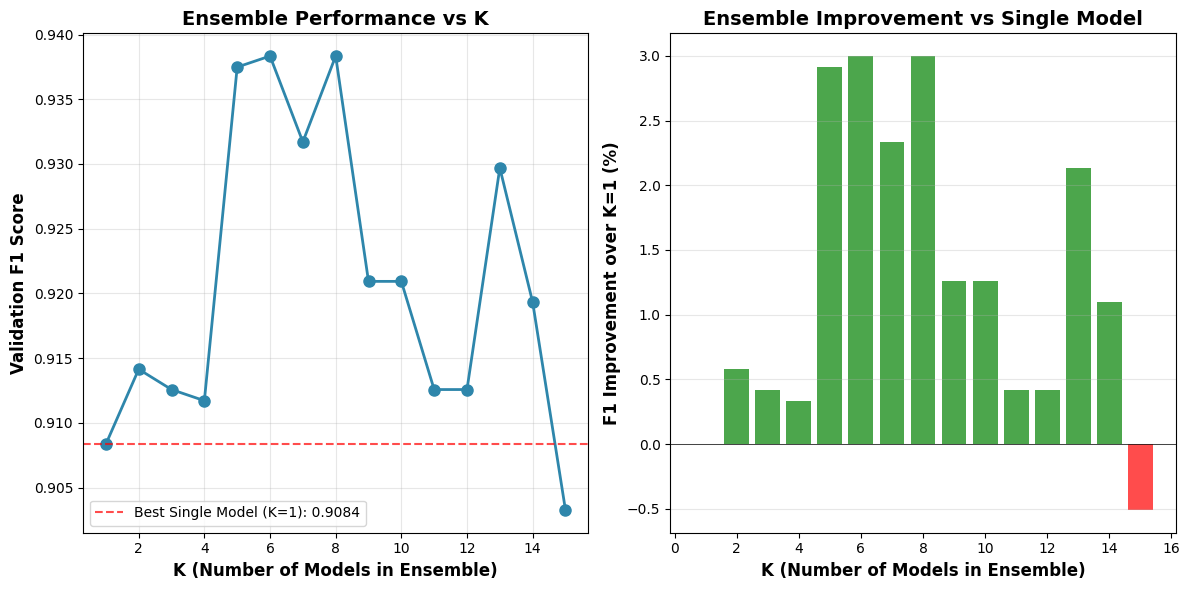


ENSEMBLE ANALYSIS SUMMARY
Best single model (K=1): F1 = 0.9084
Best ensemble (K=6): F1 = 0.9383
Improvement: +3.00%

Recommendation: Use ensemble with K=6 models


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def evaluate_topk_ensemble(study, dataLoader, max_k=20):
    """
    Evaluate ensemble performance for different values of K (top-K trials).
    
    Args:
        study: Optuna study object
        dataLoader: DataModule for loading data
        max_k: Maximum K to test (number of top models to ensemble)
    
    Returns:
        results: Dictionary with K values and corresponding F1 scores
    """
    # Get completed trials sorted by F1 score
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if not completed_trials:
        print("⚠️ No completed trials found!")
        return None
    
    sorted_trials = sorted(completed_trials, key=lambda t: t.value, reverse=True)
    max_k = min(max_k, len(sorted_trials))
    
    print(f"Evaluating ensembles with K = 1 to {max_k}")
    print(f"Total completed trials: {len(sorted_trials)}")
    print("-" * 60)
    
    # Prepare validation data
    dataLoader.setup(stage='fit', includeTestInTrain=False)
    valLoader = dataLoader.val_dataloader()
    
    # Load all top-K models and get their predictions
    all_models = []
    all_predictions = []
    all_targets = []
    
    print("Loading top models and collecting predictions...")
    for i, trial in enumerate(sorted_trials[:max_k]):
        print(f"  Loading model {i+1}/{max_k} (Trial {trial.number}, F1={trial.value:.4f})...", end=" ")
        
        try:
            # Reconstruct model architecture
            class TrialWrapper:
                def __init__(self, params):
                    self.params = params
                def suggest_categorical(self, name, choices):
                    return self.params[name]
                def suggest_int(self, name, low, high, log=False):
                    return self.params[name]
                def suggest_float(self, name, low, high, log=False):
                    return self.params[name]
            
            trial_wrapper = TrialWrapper(trial.params)
            archParams = {}
            archParams = setUpEncoder(trial_wrapper, archParams, dataLoader.getDatasetInfo())
            archParams = setUpFeedForwardHead(trial_wrapper, archParams, dataLoader.getDatasetInfo())
            
            macroArch = trial.params.get('MacroArchitecture', 'Direct')
            if macroArch == "Autoencoder":
                archParams = setUpDecoder(trial_wrapper, archParams, dataLoader.getDatasetInfo())
                archParams["ReconstructionLossWeight"] = trial.params.get('ReconstructionLossWeight', 0.5)
            
            archParams['LearningRate'] = trial.params['LearningRate']
            archParams['RegularizationWeight'] = trial.params['RegularizationWeight']
            archParams['Patience'] = trial.params['Patience']
            archParams['OutputDim'] = 3
            archParams['ClassWeightsPath'] = '../dataset/PirateProcessed/class_weights.yaml'
            
            # Find checkpoint for this trial
            import glob
            import os
            
            # Try multiple strategies to find the checkpoint:
            # Strategy 1: Look for trial number in checkpoint filename
            checkpoint_pattern = f'lightning_logs/version_*/checkpoints/trial-{trial.number}-*.ckpt'
            checkpoints = glob.glob(checkpoint_pattern)
            
            # Strategy 2: If not found, try version directory matching trial number
            if not checkpoints:
                version_dir = f'lightning_logs/version_{trial.number}/checkpoints/*.ckpt'
                checkpoints = glob.glob(version_dir)
            
            # Strategy 3: Search all checkpoints and match by timestamp or other heuristic
            if not checkpoints:
                # Try looking at recent versions (trials are likely in order)
                for offset in range(-5, 6):  # Check nearby version numbers
                    version_num = trial.number + offset
                    if version_num >= 0:
                        version_dir = f'lightning_logs/version_{version_num}/checkpoints/*.ckpt'
                        potential = glob.glob(version_dir)
                        if potential:
                            checkpoints = potential
                            break
            
            if not checkpoints:
                print("⚠️ Checkpoint not found, skipping")
                continue
            
            # Get the checkpoint (prefer ones with val_F1 in name, otherwise take the last one)
            if any('val_F1=' in ckpt for ckpt in checkpoints):
                checkpoint_path = sorted([c for c in checkpoints if 'val_F1=' in c], 
                                        key=lambda x: float(x.split('val_F1=')[1].split('.ckpt')[0]), 
                                        reverse=True)[0]
            else:
                # No F1 in name, just take the last checkpoint by name
                checkpoint_path = sorted(checkpoints)[-1]
            
            # Load model
            if macroArch == "Direct":
                model = Direct.load_from_checkpoint(checkpoint_path, params=archParams)
            else:
                model = LightningAutoencoder.load_from_checkpoint(checkpoint_path, params=archParams)
            
            model.eval()
            model = model.to('cuda' if torch.cuda.is_available() else 'cpu')
            
            # Get predictions on validation set
            model_preds = []
            targets = []
            
            with torch.no_grad():
                for batch in valLoader:
                    inputData, labels = batch
                    timeSeries, globalFeats = inputData
                    timeSeries = timeSeries.to(model.device)
                    globalFeats = globalFeats.to(model.device)
                    
                    # Get logits
                    if macroArch == "Direct":
                        logits = model(timeSeries, globalFeats)
                    else:
                        logits, _ = model((timeSeries, globalFeats))
                    
                    # Store softmax probabilities for ensemble
                    probs = torch.softmax(logits, dim=1)
                    model_preds.append(probs.cpu().numpy())
                    targets.append(labels.cpu().numpy())
            
            # Concatenate all batches
            model_preds = np.concatenate(model_preds, axis=0)
            all_predictions.append(model_preds)
            
            if i == 0:  # Store targets only once
                all_targets = np.concatenate(targets, axis=0)
            
            print("✓")
            
        except Exception as e:
            print(f"✗ Error: {e}")
            continue
    
    if not all_predictions:
        print("⚠️ No models loaded successfully!")
        return None
    
    print(f"\n✓ Successfully loaded {len(all_predictions)} models")
    print("\nEvaluating ensembles...")
    print("-" * 60)
    
    # Calculate ensemble F1 for different K values
    results = {
        'k_values': [],
        'f1_scores': [],
        'individual_f1s': []
    }
    
    from sklearn.metrics import f1_score
    
    for k in range(1, len(all_predictions) + 1):
        # Average predictions from top-K models
        ensemble_probs = np.mean(all_predictions[:k], axis=0)
        ensemble_preds = np.argmax(ensemble_probs, axis=1)
        
        # Calculate F1 score (macro average to match your training)
        f1 = f1_score(all_targets, ensemble_preds, average='macro')
        
        results['k_values'].append(k)
        results['f1_scores'].append(f1)
        
        # Also store individual model F1 for reference
        if k == 1:
            individual_preds = np.argmax(all_predictions[0], axis=1)
            individual_f1 = f1_score(all_targets, individual_preds, average='macro')
            results['individual_f1s'].append(individual_f1)
        
        print(f"  K={k:2d}: Ensemble F1 = {f1:.4f}")
    
    return results, all_predictions, all_targets

# Run the ensemble analysis
print("Starting Top-K Ensemble Analysis...")
print("=" * 60)
results = evaluate_topk_ensemble(study, dataLoader, max_k=15)

if results:
    results_dict, all_predictions, all_targets = results
    
    # Plot the results
    plt.figure(figsize=(12, 6))
    
    # Plot 1: F1 vs K
    plt.subplot(1, 2, 1)
    plt.plot(results_dict['k_values'], results_dict['f1_scores'], 
             marker='o', linewidth=2, markersize=8, color='#2E86AB')
    plt.axhline(y=results_dict['f1_scores'][0], color='red', linestyle='--', 
                label=f'Best Single Model (K=1): {results_dict["f1_scores"][0]:.4f}', alpha=0.7)
    plt.xlabel('K (Number of Models in Ensemble)', fontsize=12, fontweight='bold')
    plt.ylabel('Validation F1 Score', fontsize=12, fontweight='bold')
    plt.title('Ensemble Performance vs K', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    # Plot 2: F1 Improvement over best single model
    plt.subplot(1, 2, 2)
    best_single_f1 = results_dict['f1_scores'][0]
    improvements = [(f1 - best_single_f1) * 100 for f1 in results_dict['f1_scores']]
    colors = ['green' if imp >= 0 else 'red' for imp in improvements]
    plt.bar(results_dict['k_values'], improvements, color=colors, alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('K (Number of Models in Ensemble)', fontsize=12, fontweight='bold')
    plt.ylabel('F1 Improvement over K=1 (%)', fontsize=12, fontweight='bold')
    plt.title('Ensemble Improvement vs Single Model', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    
    plt.show()
    
    # Summary statistics
    best_k = np.argmax(results_dict['f1_scores']) + 1
    best_f1 = max(results_dict['f1_scores'])
    improvement = (best_f1 - best_single_f1) * 100
    
    print("\n" + "=" * 60)
    print("ENSEMBLE ANALYSIS SUMMARY")
    print("=" * 60)
    print(f"Best single model (K=1): F1 = {best_single_f1:.4f}")
    print(f"Best ensemble (K={best_k}): F1 = {best_f1:.4f}")
    print(f"Improvement: {improvement:+.2f}%")
    print(f"\nRecommendation: Use ensemble with K={best_k} models")
    print("=" * 60)
else:
    print("⚠️ Ensemble analysis failed - check that models can be loaded")

## 🎯 Generate Ensemble Submission

Use the optimal K-model ensemble to generate predictions for the test set.

In [ ]:
from GradientGang.Pipeline.SubmissionGenerator.SubmissionGenerator import SubmissionGenerator

class EnsembleModel(torch.nn.Module):
    """Wrapper for ensemble of models compatible with SubmissionGenerator."""
    
    def __init__(self, models, model_types):
        """
        Args:
            models: List of models
            model_types: List of model types ('Direct' or 'Autoencoder') corresponding to each model
        """
        super().__init__()
        self.models = torch.nn.ModuleList(models)
        self.model_types = model_types
        self.device = models[0].device if models else torch.device('cpu')
    
    def forward(self, x):
        """Average predictions from all models."""
        all_logits = []
        
        # Handle input format: could be tuple (timeSeries, globalFeats) or just features
        if isinstance(x, tuple) and len(x) == 2:
            timeSeries, globalFeats = x
        else:
            # Single input
            timeSeries = x
            globalFeats = None
        
        for i, model in enumerate(self.models):
            model.eval()
            with torch.no_grad():
                # Call model based on its type
                model_type = self.model_types[i]
                
                if model_type == "Direct":
                    # Direct models expect: (timeSeries, globalFeats)
                    output = model(timeSeries, globalFeats)
                else:  # Autoencoder
                    # Autoencoder models expect: ((timeSeries, globalFeats),)
                    output = model((timeSeries, globalFeats))
                
                # Handle different output formats
                if isinstance(output, tuple):
                    logits = output[0]
                else:
                    logits = output
                
                all_logits.append(logits)
        
        # Average logits and return
        ensemble_logits = torch.mean(torch.stack(all_logits), dim=0)
        return ensemble_logits
    
    def eval(self):
        """Set all models to eval mode."""
        for model in self.models:
            model.eval()
        return self

def generate_ensemble_submission(study, dataLoader, optimal_k, submission_path='../Submissions/submission_ensemble.csv'):
    """
    Generate test predictions using optimal K-model ensemble with SubmissionGenerator.
    
    Args:
        study: Optuna study object
        dataLoader: DataModule for loading data
        optimal_k: Number of top models to use in ensemble
        submission_path: Path to save the submission file
    """
    import pandas as pd
    import glob
    import os
    
    # Get top K trials
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    sorted_trials = sorted(completed_trials, key=lambda t: t.value, reverse=True)[:optimal_k]
    
    print(f"Generating ensemble predictions with K={optimal_k} models")
    print("=" * 60)
    
    # Prepare test data
    dataLoader.setup(stage='test', includeTestInTrain=False)
    testLoader = dataLoader.test_dataloader()
    
    # Load models and create ensemble
    loaded_models = []
    model_types = []
    
    print("Loading models for ensemble...")
    for i, trial in enumerate(sorted_trials):
        print(f"  Loading model {i+1}/{optimal_k} (Trial {trial.number}, Val F1={trial.value:.4f})...", end=" ")
        
        try:
            # Reconstruct model architecture
            class TrialWrapper:
                def __init__(self, params):
                    self.params = params
                def suggest_categorical(self, name, choices):
                    return self.params[name]
                def suggest_int(self, name, low, high, log=False):
                    return self.params[name]
                def suggest_float(self, name, low, high, log=False):
                    return self.params[name]
            
            trial_wrapper = TrialWrapper(trial.params)
            archParams = {}
            archParams = setUpEncoder(trial_wrapper, archParams, dataLoader.getDatasetInfo())
            archParams = setUpFeedForwardHead(trial_wrapper, archParams, dataLoader.getDatasetInfo())
            
            macroArch = trial.params.get('MacroArchitecture', 'Direct')
            if macroArch == "Autoencoder":
                archParams = setUpDecoder(trial_wrapper, archParams, dataLoader.getDatasetInfo())
                archParams["ReconstructionLossWeight"] = trial.params.get('ReconstructionLossWeight', 0.5)
            
            archParams['LearningRate'] = trial.params['LearningRate']
            archParams['RegularizationWeight'] = trial.params['RegularizationWeight']
            archParams['Patience'] = trial.params['Patience']
            archParams['OutputDim'] = 3
            archParams['ClassWeightsPath'] = '../dataset/PirateProcessed/class_weights.yaml'
            
            # Find checkpoint
            checkpoint_pattern = f'lightning_logs/version_*/checkpoints/trial-{trial.number}-*.ckpt'
            checkpoints = glob.glob(checkpoint_pattern)
            
            if not checkpoints:
                version_dir = f'lightning_logs/version_{trial.number}/checkpoints/*.ckpt'
                checkpoints = glob.glob(version_dir)
            
            if not checkpoints:
                for offset in range(-5, 6):
                    version_num = trial.number + offset
                    if version_num >= 0:
                        version_dir = f'lightning_logs/version_{version_num}/checkpoints/*.ckpt'
                        potential = glob.glob(version_dir)
                        if potential:
                            checkpoints = potential
                            break
            
            if not checkpoints:
                print("⚠️ Checkpoint not found, skipping")
                continue
            
            if any('val_F1=' in ckpt for ckpt in checkpoints):
                checkpoint_path = sorted([c for c in checkpoints if 'val_F1=' in c], 
                                        key=lambda x: float(x.split('val_F1=')[1].split('.ckpt')[0]), 
                                        reverse=True)[0]
            else:
                checkpoint_path = sorted(checkpoints)[-1]
            
            # Load model
            if macroArch == "Direct":
                model = Direct.load_from_checkpoint(checkpoint_path, params=archParams)
            else:
                model = LightningAutoencoder.load_from_checkpoint(checkpoint_path, params=archParams)
            
            model.eval()
            model = model.to('cuda' if torch.cuda.is_available() else 'cpu')
            loaded_models.append(model)
            model_types.append(macroArch)
            
            print("✓")
            
        except Exception as e:
            print(f"✗ Error: {e}")
            continue
    
    if not loaded_models:
        print("⚠️ No models loaded successfully!")
        return None
    
    print(f"\n✓ Successfully loaded {len(loaded_models)} models")
    print("\nCreating ensemble model...")
    
    # Create ensemble model wrapper
    ensemble_model = EnsembleModel(loaded_models, model_types)
    
    # Use SubmissionGenerator with ensemble model
    print("Generating submission using SubmissionGenerator...")
    submission_generator = SubmissionGenerator(
        model=ensemble_model,
        dataloader=testLoader,
        label_mapping={0: "no_pain", 1: "low_pain", 2: "high_pain"}
    )
    
    # Generate submission
    submission_df = submission_generator.generate_submission(output_path=submission_path)
    
    print("\n" + "=" * 60)
    print("SUBMISSION GENERATED")
    print("=" * 60)
    print(f"File saved to: {submission_path}")
    print(f"Total predictions: {len(submission_df)}")
    print(f"\nPrediction distribution:")
    label_counts = submission_df['label'].value_counts()
    for label in ['no_pain', 'low_pain', 'high_pain']:
        count = label_counts.get(label, 0)
        percentage = count / len(submission_df) * 100
        print(f"  {label}: {count:4d} samples ({percentage:5.2f}%)")
    print("=" * 60)
    
    return submission_df

# Generate submission using optimal K from ensemble analysis
if results:
    results_dict, all_predictions, all_targets = results
    optimal_k = np.argmax(results_dict['f1_scores']) + 1
    
    print(f"\n🎯 Using optimal K={optimal_k} for ensemble submission\n")
    
    submission_df = generate_ensemble_submission(
        study, 
        dataLoader, 
        optimal_k=optimal_k,
        submission_path='../Submissions/submission_ensemble_optimal.csv'
    )
else:
    print("⚠️ No ensemble results available. Run the ensemble analysis first!")


🎯 Using optimal K=6 for ensemble submission

Generating ensemble predictions with K=6 models
Generating ensemble predictions with K=6 models
Loading models for ensemble...
  Loading model 1/6 (Trial 37, Val F1=0.9394)... ✓
  Loading model 2/6 (Trial 54, Val F1=0.9394)... Loading models for ensemble...
  Loading model 1/6 (Trial 37, Val F1=0.9394)... ✓
  Loading model 2/6 (Trial 54, Val F1=0.9394)... ✓
  Loading model 3/6 (Trial 9, Val F1=0.9318)... ✓
  Loading model 4/6 (Trial 55, Val F1=0.9318)... ✓
  Loading model 3/6 (Trial 9, Val F1=0.9318)... ✓
  Loading model 4/6 (Trial 55, Val F1=0.9318)... ✓
  Loading model 5/6 (Trial 11, Val F1=0.9242)... ✓
  Loading model 6/6 (Trial 49, Val F1=0.9242)... ✓
  Loading model 5/6 (Trial 11, Val F1=0.9242)... ✓
  Loading model 6/6 (Trial 49, Val F1=0.9242)... ✓

✓ Successfully loaded 6 models

Creating ensemble model...
Generating submission using SubmissionGenerator...
✓

✓ Successfully loaded 6 models

Creating ensemble model...
Generating subm

## Load and Evaluate Best Model

Load the best checkpoint and evaluate it on the validation set.

In [ ]:
# Reconstruct the best model from best trial parameters
from pytorch_lightning import Trainer
from torchmetrics import ConfusionMatrix
from GradientGang.Pipeline.Architectures.LightningAutoencoder import LightningAutoencoder
import torch

best_params = study.best_params
print("Reconstructing best model with parameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

# Create a dummy trial to reuse setup functions
class BestTrial:
    def __init__(self, params):
        self.params = params
    
    def suggest_categorical(self, name, choices):
        return self.params[name]
    
    def suggest_int(self, name, low, high, log=False):
        return self.params[name]
    
    def suggest_float(self, name, low, high, log=False):
        return self.params[name]

best_trial = BestTrial(best_params)

# Reconstruct architecture
archParams = {}
archParams = setUpEncoder(best_trial, archParams, dataLoader.getDatasetInfo())
archParams = setUpFeedForwardHead(best_trial, archParams, dataLoader.getDatasetInfo())

# Check if autoencoder
macroArchitecture = best_params.get('MacroArchitecture', 'Direct')
if macroArchitecture == "Autoencoder":
    archParams = setUpDecoder(best_trial, archParams, dataLoader.getDatasetInfo())
    archParams["ReconstructionLossWeight"] = best_params['ReconstructionLossWeight']

archParams['LearningRate'] = best_params['LearningRate']
archParams['RegularizationWeight'] = best_params['RegularizationWeight']
archParams['Patience'] = best_params['Patience']
archParams['OutputDim'] = dataLoader.getDatasetInfo()['numClasses']
archParams['ClassWeightsPath'] = '../dataset/PirateProcessed/class_weights.yaml'

# Find the best checkpoint path (search in lightning_logs)
import os
import glob

# Get the most recent version directory
log_dirs = sorted(glob.glob('../lightning_logs/version_*'), key=os.path.getmtime, reverse=True)
if log_dirs:
    best_checkpoint_path = None
    for log_dir in log_dirs:
        checkpoints = glob.glob(os.path.join(log_dir, 'checkpoints', '*.ckpt'))
        if checkpoints:
            # Get the checkpoint with best metric in filename
            checkpoints = sorted(checkpoints, key=lambda x: float(x.split('val_F1=')[1].split('.ckpt')[0]) if 'val_F1=' in x else 0.0, reverse=True)
            best_checkpoint_path = checkpoints[0]
            break
    
    if best_checkpoint_path:
        print(f"\nLoading checkpoint: {best_checkpoint_path}")
        
        # Load appropriate model type
        if macroArchitecture == "Direct":
            model = Direct.load_from_checkpoint(best_checkpoint_path, **archParams)
        else:
            model = LightningAutoencoder.load_from_checkpoint(best_checkpoint_path, **archParams)
        
        # Evaluate on validation set
        trainer = Trainer(logger=False, enable_checkpointing=False)
        val_results = trainer.validate(model, datamodule=dataLoader)
        
        print(f"\nValidation Results:")
        print(f"  F1 Score: {val_results[0]['val_F1']:.4f}")
        print(f"  Loss: {val_results[0]['val_loss']:.4f}")
    else:
        print("No checkpoint found in lightning_logs!")
else:
    print("No log directories found!")

## Optional: Generate Submission

If you want to generate predictions for the test set, run this cell.

In [ ]:
# Generate predictions for test set
import pandas as pd

if best_checkpoint_path:
    # Load test data
    test_loader = dataLoader.test_dataloader()
    
    # Set model to eval mode
    model.eval()
    model = model.to('cuda' if torch.cuda.is_available() else 'cpu')
    
    all_predictions = []
    
    with torch.no_grad():
        for batch in test_loader:
            timeSeries, globalFeats, _ = batch
            timeSeries = timeSeries.to(model.device)
            globalFeats = globalFeats.to(model.device)
            
            logits = model(timeSeries, globalFeats)
            predictions = torch.argmax(logits, dim=1)
            all_predictions.extend(predictions.cpu().numpy())
    
    # Create submission dataframe
    submission_df = pd.DataFrame({
        'Id': range(len(all_predictions)),
        'Predicted': all_predictions
    })
    
    # Save submission
    submission_path = f'../Submissions/submission_optuna_general2.csv'
    submission_df.to_csv(submission_path, index=False)
    print(f"Submission saved to: {submission_path}")
    print(f"Total predictions: {len(all_predictions)}")
    print(f"Prediction distribution:")
    print(submission_df['Predicted'].value_counts().sort_index())
else:
    print("No checkpoint loaded, skipping submission generation.")